# Анализ партий на Lichess

Партии загружаются напрямую из [Lichess API](https://lichess.org/api#tag/Games/operation/apiGamesUser) по имени пользователя — без ручной выгрузки файлов. Дальше PGN разбирается через `python-chess`, заголовки партий собираются в один `pandas.DataFrame`, и на его основе строятся все графики ниже: по соперникам и результатам, по времени и дате, по дебютам, контролю времени и типам завершения партий.

Раздел «Выводы» в конце ноутбука собирает главные наблюдения по данным.

In [1]:
import io
import re
from datetime import datetime, timedelta

import chess.pgn
import matplotlib.pyplot as plt
import pandas as pd
import requests

In [2]:
username = 'AndrewSalmin'

WEEKDAY_NAMES_SHORT_RU = ['пн', 'вт', 'ср', 'чт', 'пт', 'сб', 'вс']
WEEKDAY_NAMES_FULL_RU = [
    'понедельник', 'вторник', 'среда', 'четверг',
    'пятница', 'суббота', 'воскресенье',
]

SPEED_ORDER = ['ultrabullet', 'bullet', 'blitz', 'rapid', 'classical', 'correspondence']

RESULT_ORDER = ['win', 'loss', 'draw', 'other']
RESULT_LABELS = {'win': 'победа', 'loss': 'поражение', 'draw': 'ничья', 'other': 'без результата'}
RESULT_COLORS = {'win': 'tab:green', 'loss': 'tab:red', 'draw': 'tab:gray', 'other': 'tab:orange'}

COLOR_LABELS_RU = {'white': 'белые', 'black': 'чёрные'}

BAR_GROUP_WIDTH = 0.25

In [3]:
def download_pgn_games(username: str) -> str:
    url = f'https://lichess.org/api/games/user/{username}'
    # без User-Agent Lichess отдаёт HTML-заглушку (антибот) вместо API-ответа
    headers = {'User-Agent': 'chess-analysis (github.com/andrewsalmin/chess-analysis)'}
    # opening=true — чтобы в заголовках партий пришло название дебюта, а не только код ECO
    params = {'opening': 'true'}
    response = requests.get(url, headers=headers, params=params, timeout=60)

    if response.status_code == 404:
        raise ValueError(f'Пользователь "{username}" не найден на Lichess')
    response.raise_for_status()

    return response.text

pgn_games_string = download_pgn_games(username)

assert pgn_games_string, 'Пользователь не сыграл ни одной партии'

In [4]:
pgn_games = io.StringIO(pgn_games_string)
games = []
while True:
    game = chess.pgn.read_game(pgn_games)
    if game is None:
        break
    games.append(game)

print(f'Прочитано партий: {len(games)}')

Прочитано партий: 1254


## Подготовка данных

In [5]:
def my_result(white: str, black: str, result: str) -> str:
    if result == '1/2-1/2':
        return 'draw'
    if (white == username and result == '1-0') or (black == username and result == '0-1'):
        return 'win'
    if (white == username and result == '0-1') or (black == username and result == '1-0'):
        return 'loss'
    return 'other'  # партия прервана/отменена, результата нет


def parse_rated(event: str) -> bool:
    # заголовок Event у Lichess строчными: 'rated blitz game' / 'casual bullet tournament ...';
    # у командных баттлов и арен с собственным названием (GoldLeague и т.п.) префикса нет вовсе
    match = re.match(r'^(rated|casual)\b', event, re.IGNORECASE)
    return match.group(1).lower() == 'rated' if match else None


def parse_speed(time_control: str) -> str:
    # скорость считаем по TimeControl (как сам Lichess), а не по тексту Event —
    # так классифицируются и партии из турниров с произвольным названием
    if '+' not in time_control:
        return 'correspondence'
    base_str, increment_str = time_control.split('+', 1)
    try:
        base, increment = int(base_str), int(increment_str)
    except ValueError:
        return None
    estimated_seconds = base + 40 * increment
    if estimated_seconds < 30:
        return 'ultrabullet'
    if estimated_seconds < 180:
        return 'bullet'
    if estimated_seconds < 480:
        return 'blitz'
    if estimated_seconds < 1500:
        return 'rapid'
    return 'classical'


def parse_elo(value) -> float:
    try:
        return float(value)
    except (TypeError, ValueError):
        return float('nan')


rows = []
for game in games:
    headers = game.headers
    white = headers.get('White', '')
    black = headers.get('Black', '')
    result = headers.get('Result', '*')
    time_control = headers.get('TimeControl', '')
    rated = parse_rated(headers.get('Event', ''))
    speed = parse_speed(time_control)
    white_elo = parse_elo(headers.get('WhiteElo'))
    black_elo = parse_elo(headers.get('BlackElo'))
    utc_dt = datetime.strptime(
        headers['UTCDate'] + ' ' + headers['UTCTime'], '%Y.%m.%d %H:%M:%S'
    )
    rows.append({
        'event': headers.get('Event', ''),
        'white': white,
        'black': black,
        'opponent': black if white == username else white,
        'color': 'white' if white == username else 'black',
        'result': my_result(white, black, result),
        'rated': rated,
        'speed': speed,
        'time_control': time_control,
        'eco': headers.get('ECO', ''),
        'opening': headers.get('Opening') or headers.get('ECO', ''),
        'termination': headers.get('Termination', ''),
        'my_elo': white_elo if white == username else black_elo,
        'opp_elo': black_elo if white == username else white_elo,
        'num_moves': (len(list(game.mainline_moves())) + 1) // 2,
        'utc_datetime': utc_dt,
        'ekb_datetime': utc_dt + timedelta(hours=5),
    })

df = pd.DataFrame(rows)
df['rating_diff'] = df['my_elo'] - df['opp_elo']
df['ekb_date'] = df['ekb_datetime'].dt.date
df['year'] = df['ekb_datetime'].dt.year
df['month'] = df['ekb_datetime'].dt.month
df['day'] = df['ekb_datetime'].dt.day
df['weekday'] = df['ekb_datetime'].dt.weekday
df['hour'] = df['ekb_datetime'].dt.hour

assert len(df) == len(games)

other_count = (df['result'] == 'other').sum()
if other_count:
    print(f'Партий без результата (аборты и т.п.): {other_count}')

decisive = df[df['result'].isin(['win', 'loss', 'draw'])]

## Анализ хедеров

### Топ-10 событий по числу партий

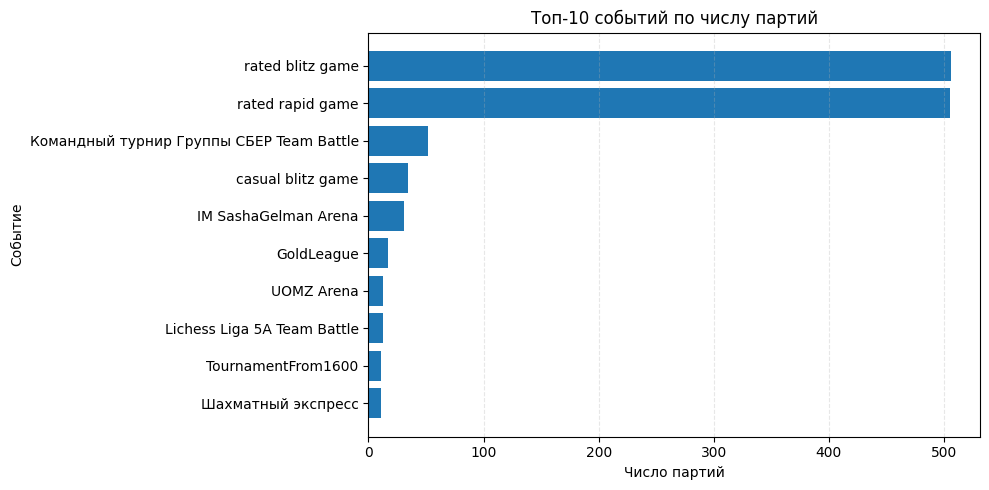

In [6]:
top_events = df['event'].value_counts().head(10)

plt.figure(figsize=(10, 5))
plt.barh(top_events.index[::-1], top_events.values[::-1])
plt.title('Топ-10 событий по числу партий')
plt.xlabel('Число партий')
plt.ylabel('Событие')
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()

### Топ-10 соперников по числу партий

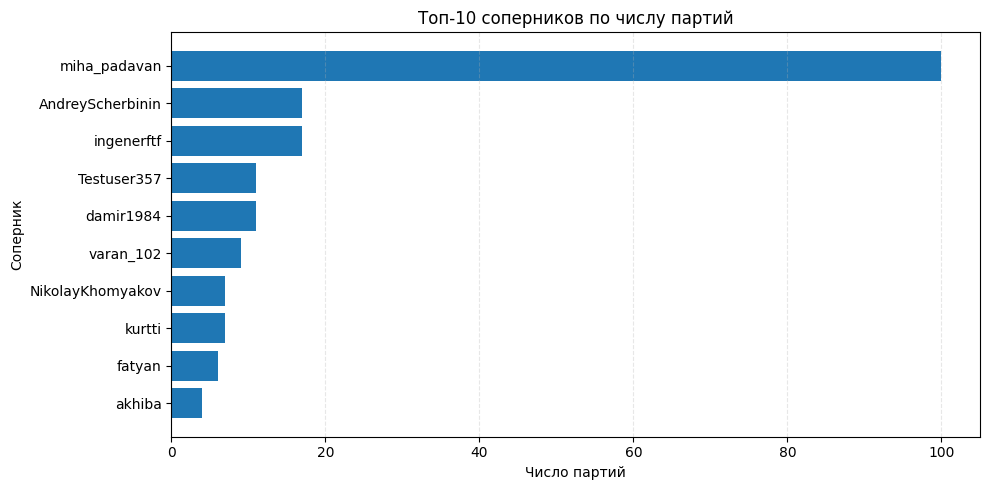

In [7]:
top_opponents = df['opponent'].value_counts().head(10)

plt.figure(figsize=(10, 5))
plt.barh(top_opponents.index[::-1], top_opponents.values[::-1])
plt.title('Топ-10 соперников по числу партий')
plt.xlabel('Число партий')
plt.ylabel('Соперник')
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()

### Распределение партий по результатам

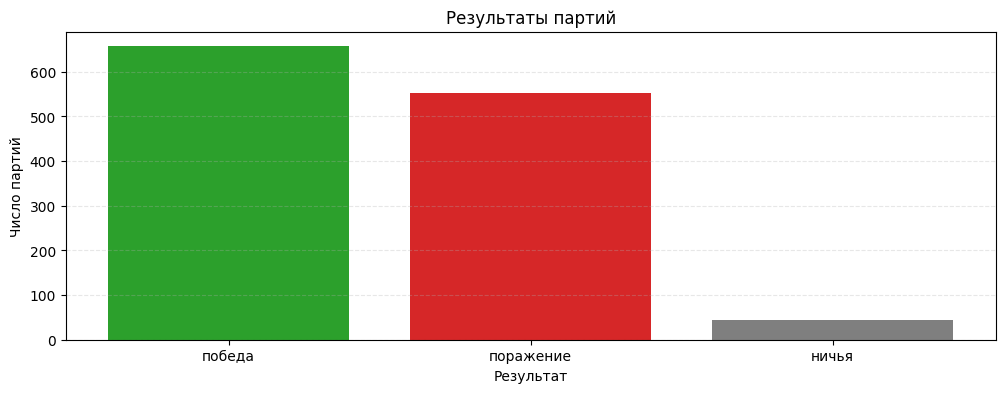

In [8]:
results_counts = df['result'].value_counts().reindex(RESULT_ORDER, fill_value=0)
results_counts = results_counts[results_counts > 0]

plt.figure(figsize=(12, 4))
plt.bar(
    [RESULT_LABELS[r] for r in results_counts.index],
    results_counts.values,
    color=[RESULT_COLORS[r] for r in results_counts.index],
)
plt.title('Результаты партий')
plt.xlabel('Результат')
plt.ylabel('Число партий')
plt.grid(axis='y', alpha=0.3, linestyle='--')

### Результативность по цвету фигур

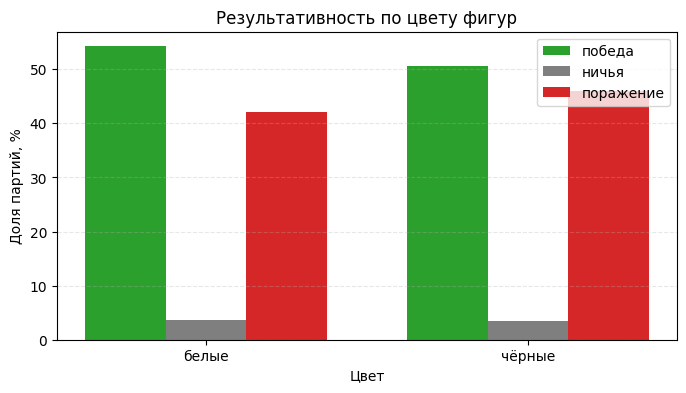

In [9]:
color_counts = (
    decisive.groupby('color')['result']
    .value_counts()
    .unstack(fill_value=0)
    .reindex(columns=['win', 'draw', 'loss'], fill_value=0)
    .reindex(['white', 'black'])
)
color_pct = color_counts.div(color_counts.sum(axis=1), axis=0) * 100

x = range(len(color_pct))
plt.figure(figsize=(8, 4))
for i, result in enumerate(['win', 'draw', 'loss']):
    plt.bar(
        [xi + (i - 1) * BAR_GROUP_WIDTH for xi in x],
        color_pct[result],
        width=BAR_GROUP_WIDTH,
        label=RESULT_LABELS[result],
        color=RESULT_COLORS[result],
    )
plt.title('Результативность по цвету фигур')
plt.xlabel('Цвет')
plt.ylabel('Доля партий, %')
plt.xticks(list(x), [COLOR_LABELS_RU[c] for c in color_pct.index])
plt.legend()
plt.grid(axis='y', alpha=0.3, linestyle='--')

### Результативность по скорости игры

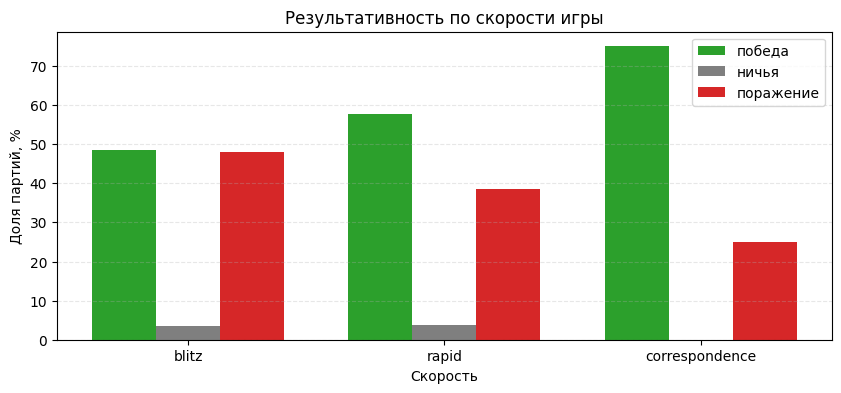

In [10]:
speed_counts = (
    decisive.dropna(subset=['speed'])
    .groupby('speed')['result']
    .value_counts()
    .unstack(fill_value=0)
    .reindex(columns=['win', 'draw', 'loss'], fill_value=0)
)
speed_counts = speed_counts.reindex([s for s in SPEED_ORDER if s in speed_counts.index])
speed_pct = speed_counts.div(speed_counts.sum(axis=1), axis=0) * 100

x = range(len(speed_pct))
plt.figure(figsize=(10, 4))
for i, result in enumerate(['win', 'draw', 'loss']):
    plt.bar(
        [xi + (i - 1) * BAR_GROUP_WIDTH for xi in x],
        speed_pct[result],
        width=BAR_GROUP_WIDTH,
        label=RESULT_LABELS[result],
        color=RESULT_COLORS[result],
    )
plt.title('Результативность по скорости игры')
plt.xlabel('Скорость')
plt.ylabel('Доля партий, %')
plt.xticks(list(x), speed_pct.index)
plt.legend()
plt.grid(axis='y', alpha=0.3, linestyle='--')

## Рейтинг

### Рейтинг во времени по скорости игры

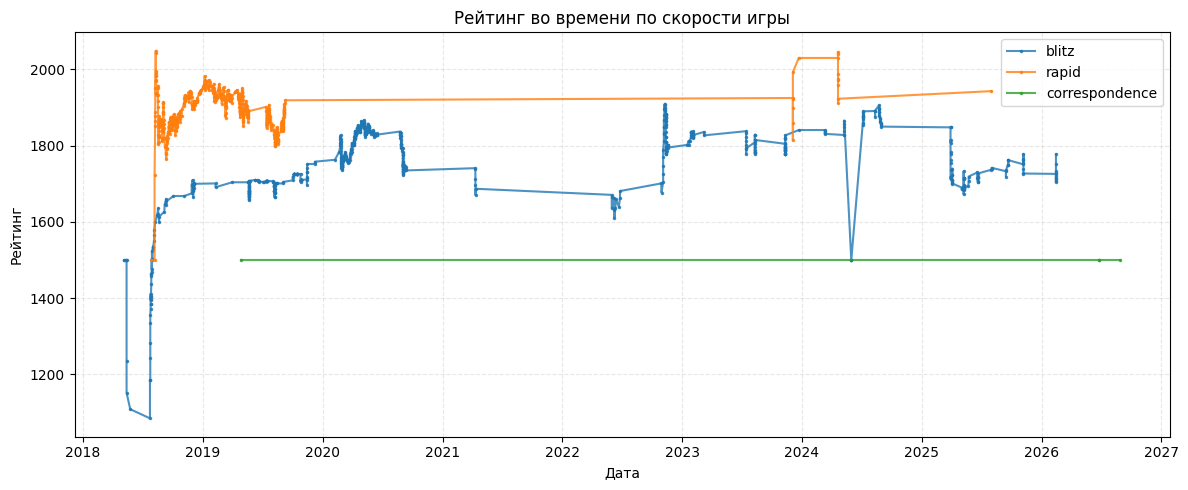

In [11]:
df_rated_history = df.dropna(subset=['my_elo']).sort_values('ekb_datetime')

plt.figure(figsize=(12, 5))
for speed in SPEED_ORDER:
    subset = df_rated_history[df_rated_history['speed'] == speed]
    if subset.empty:
        continue
    plt.plot(
        subset['ekb_datetime'], subset['my_elo'],
        marker='.', markersize=3, linestyle='-', alpha=0.8, label=speed,
    )
plt.title('Рейтинг во времени по скорости игры')
plt.xlabel('Дата')
plt.ylabel('Рейтинг')
plt.legend()
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()

## Анализ даты и времени партий

#### Распределение партий по годам

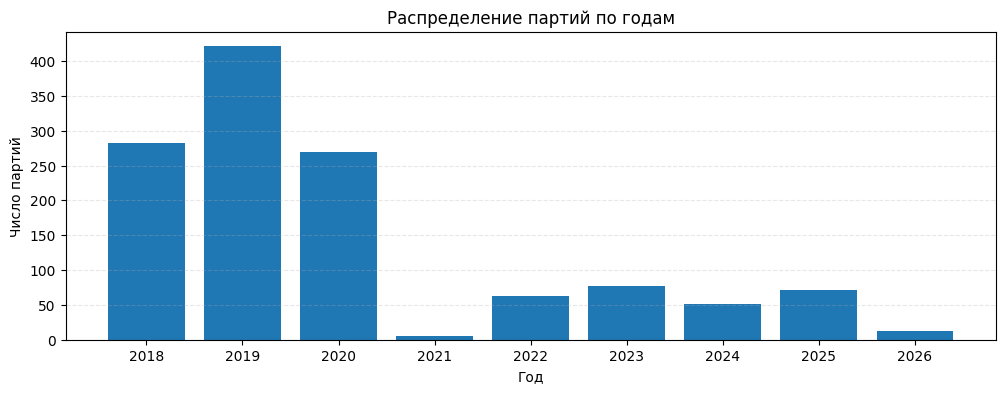

In [12]:
years_counts = df['year'].value_counts().sort_index()

plt.figure(figsize=(12, 4))
plt.bar(years_counts.index, years_counts.values)
plt.title('Распределение партий по годам')
plt.xlabel('Год')
plt.ylabel('Число партий')
plt.xticks(years_counts.index)
plt.grid(axis='y', alpha=0.3, linestyle='--')

#### Распределение партий по месяцам

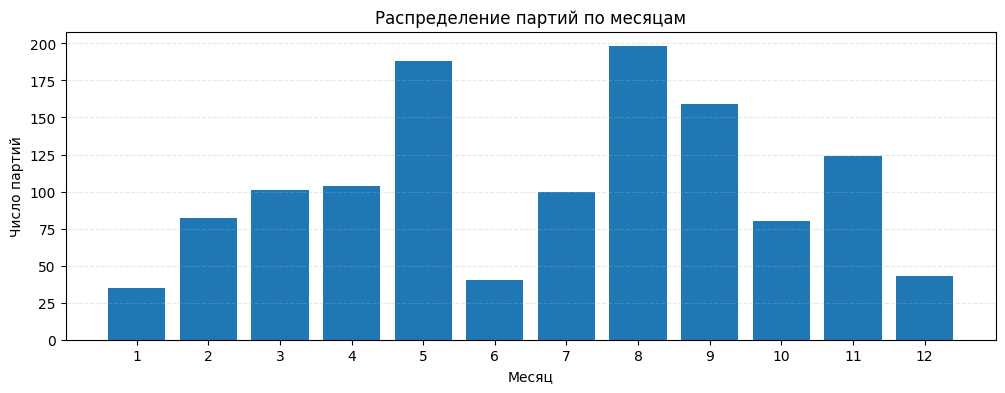

In [13]:
months_counts = df['month'].value_counts().reindex(range(1, 13), fill_value=0)

plt.figure(figsize=(12, 4))
plt.bar(months_counts.index, months_counts.values)
plt.title('Распределение партий по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Число партий')
plt.xticks(range(1, 13))
plt.grid(axis='y', alpha=0.3, linestyle='--')

#### Распределение партий по числам месяца

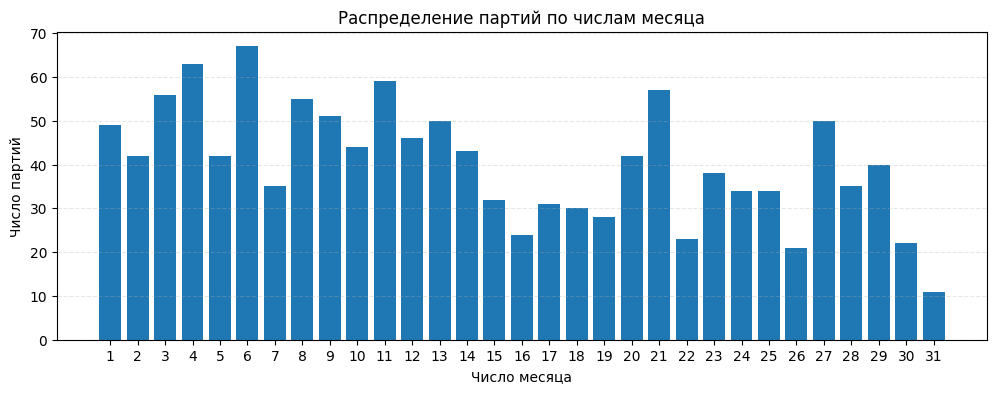

In [14]:
days_counts = df['day'].value_counts().reindex(range(1, 32), fill_value=0)

plt.figure(figsize=(12, 4))
plt.bar(days_counts.index, days_counts.values)
plt.title('Распределение партий по числам месяца')
plt.xlabel('Число месяца')
plt.ylabel('Число партий')
plt.xticks(range(1, 32))
plt.grid(axis='y', alpha=0.3, linestyle='--')

#### Распределение партий по дням недели

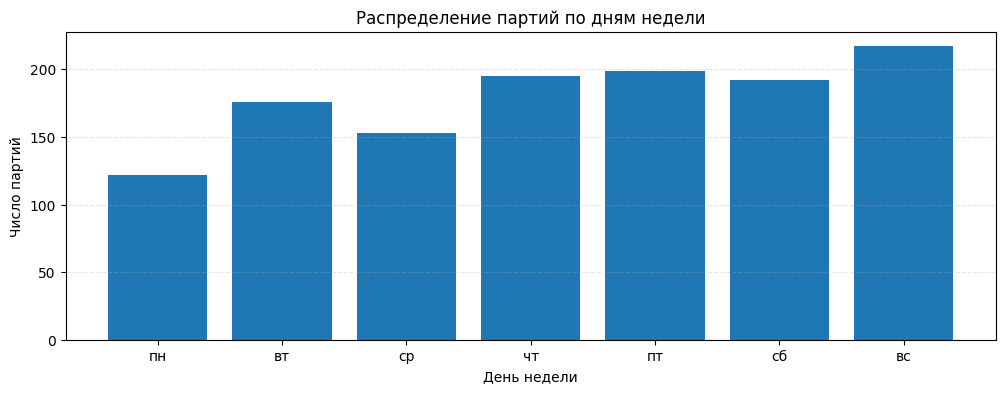

In [15]:
weekdays_counts = df['weekday'].value_counts().reindex(range(7), fill_value=0)

plt.figure(figsize=(12, 4))
plt.bar(WEEKDAY_NAMES_SHORT_RU, weekdays_counts.values)
plt.title('Распределение партий по дням недели')
plt.xlabel('День недели')
plt.ylabel('Число партий')
plt.grid(axis='y', alpha=0.3, linestyle='--')

#### Распределение партий по времени суток

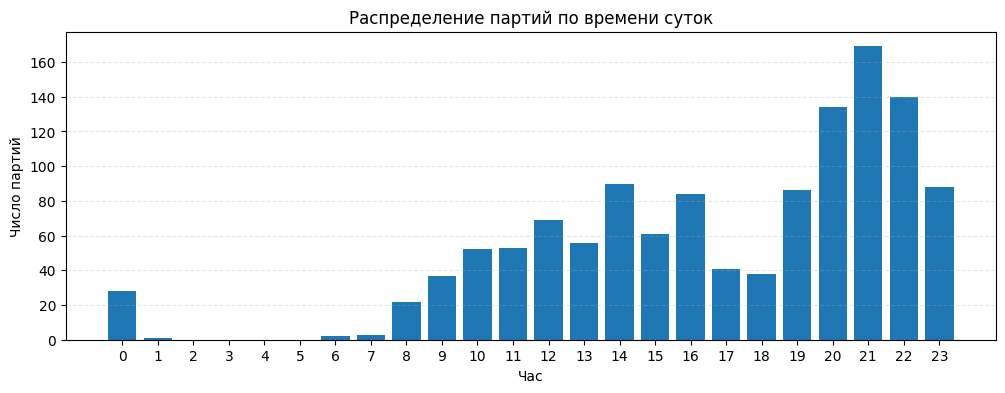

In [16]:
hours_counts = df['hour'].value_counts().reindex(range(24), fill_value=0)

plt.figure(figsize=(12, 4))
plt.bar(hours_counts.index, hours_counts.values)
plt.title('Распределение партий по времени суток')
plt.xlabel('Час')
plt.ylabel('Число партий')
plt.xticks(range(24))
plt.grid(axis='y', alpha=0.3, linestyle='--')

#### Тепловая карта: день недели × час

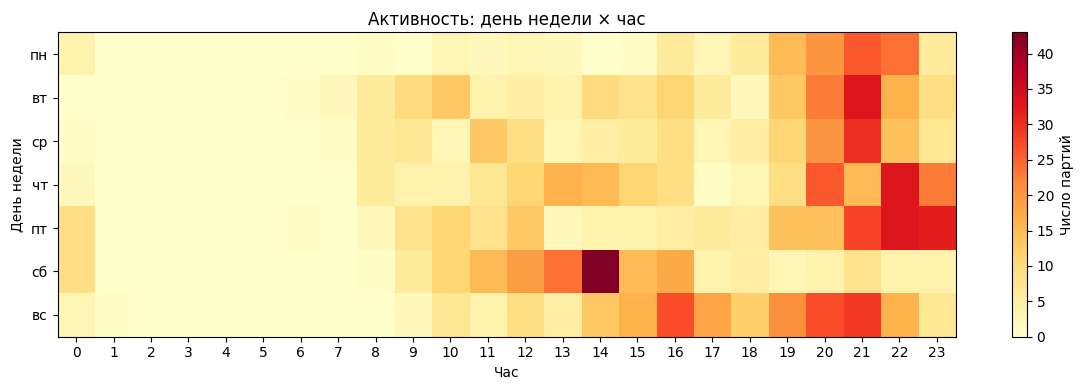

In [17]:
activity = (
    df.groupby(['weekday', 'hour']).size()
    .reindex(pd.MultiIndex.from_product([range(7), range(24)], names=['weekday', 'hour']), fill_value=0)
    .unstack('hour')
)

plt.figure(figsize=(12, 4))
plt.imshow(activity.values, aspect='auto', cmap='YlOrRd')
plt.colorbar(label='Число партий')
plt.yticks(range(7), WEEKDAY_NAMES_SHORT_RU)
plt.xticks(range(24), range(24))
plt.title('Активность: день недели × час')
plt.xlabel('Час')
plt.ylabel('День недели')
plt.tight_layout()

#### Динамика результативности (скользящее среднее)

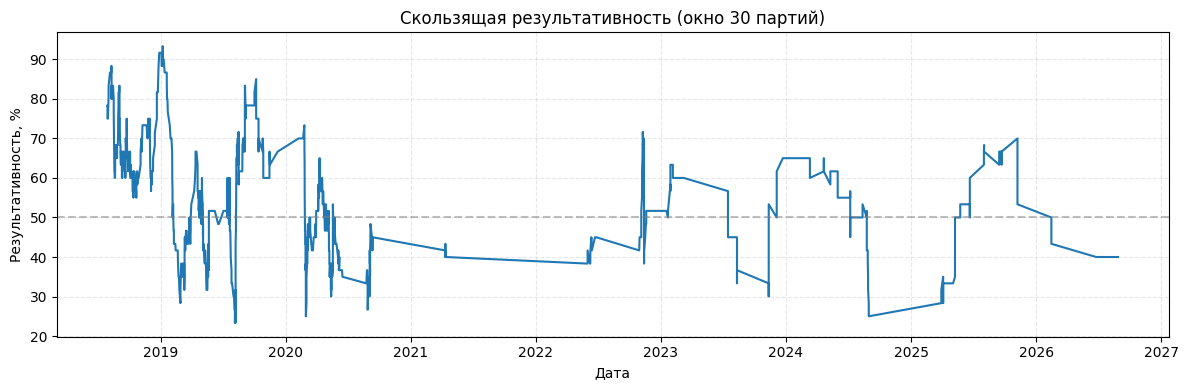

In [18]:
WINRATE_WINDOW = 30

decisive_chrono = decisive.sort_values('ekb_datetime').copy()
decisive_chrono['score'] = decisive_chrono['result'].map({'win': 1.0, 'draw': 0.5, 'loss': 0.0})
decisive_chrono['rolling_winrate'] = (
    decisive_chrono['score'].rolling(WINRATE_WINDOW, min_periods=WINRATE_WINDOW).mean() * 100
)

plt.figure(figsize=(12, 4))
plt.plot(decisive_chrono['ekb_datetime'], decisive_chrono['rolling_winrate'])
plt.axhline(50, color='gray', linestyle='--', alpha=0.5)
plt.title(f'Скользящая результативность (окно {WINRATE_WINDOW} партий)')
plt.xlabel('Дата')
plt.ylabel('Результативность, %')
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()

#### Максимальное число партий, сыгранных за день

In [19]:
games_per_day = df['ekb_date'].value_counts()
max_games_per_day = games_per_day.max()

print(f'Максимальное число партий: {max_games_per_day}\nБыло сыграно:')
for d, n in games_per_day.items():
    if n == max_games_per_day:
        print(f'{d} ({WEEKDAY_NAMES_FULL_RU[d.weekday()]})')

Максимальное число партий: 26
Было сыграно:
2019-05-21 (вторник)


#### Самые длинные серии партий (каждый день серии сыграна хотя бы одна партия)

In [20]:
def compute_streaks(games_per_day: pd.Series) -> dict:
    dates = sorted(games_per_day.index)
    streaks = {}

    streak_start = dates[0]
    streak_days = 1
    streak_games = games_per_day[dates[0]]

    for prev_date, date in zip(dates, dates[1:]):
        if date - prev_date == timedelta(days=1):
            streak_days += 1
            streak_games += games_per_day[date]
        else:
            streaks[streak_start] = (streak_days, streak_games)
            streak_start = date
            streak_days = 1
            streak_games = games_per_day[date]

    streaks[streak_start] = (streak_days, streak_games)  # не забыть последнюю (текущую) серию
    return streaks


streaks = compute_streaks(games_per_day)
max_days = max(days for days, _ in streaks.values())
max_games = max(games_count for _, games_count in streaks.values())

print('Самые длинные серии по числу дней:')
for start, (days, games_count) in streaks.items():
    if days == max_days:
        print(f'{start}: дни {days}, партии {games_count}')

print()

print('Самые длинные серии по числу партий:')
for start, (days, games_count) in streaks.items():
    if games_count == max_games:
        print(f'{start}: дни {days}, партии {games_count}')

Самые длинные серии по числу дней:
2020-04-14: дни 19, партии 26

Самые длинные серии по числу партий:
2019-05-11: дни 11, партии 52


#### Самые длинные серии побед/поражений подряд (по партиям)

In [21]:
def longest_streak(results: list, target: str) -> int:
    best = current = 0
    for r in results:
        current = current + 1 if r == target else 0
        best = max(best, current)
    return best


results_seq = decisive.sort_values('ekb_datetime')['result'].tolist()

print(f'Самая длинная серия побед подряд: {longest_streak(results_seq, "win")}')
print(f'Самая длинная серия поражений подряд: {longest_streak(results_seq, "loss")}')

Самая длинная серия побед подряд: 23
Самая длинная серия поражений подряд: 11


### Распределение партий по контролям

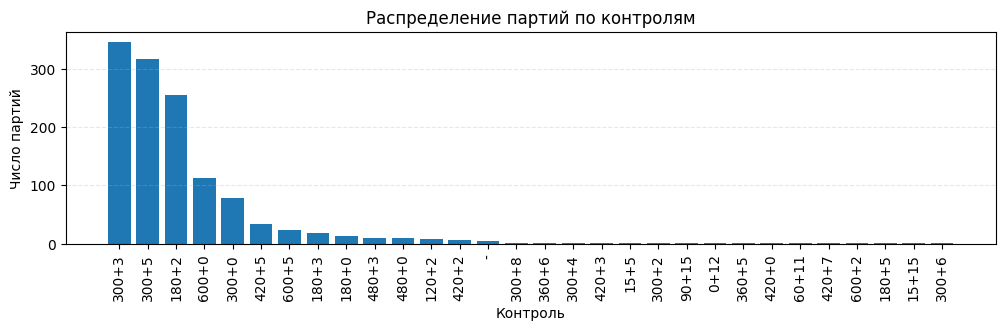

In [22]:
time_controls_counts = df['time_control'].value_counts()

plt.figure(figsize=(12, 4))
plt.bar(time_controls_counts.index, time_controls_counts.values)
plt.title('Распределение партий по контролям')
plt.xlabel('Контроль')
plt.ylabel('Число партий')
plt.xticks(rotation=90)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.subplots_adjust(bottom=0.35)

### Дебюты

#### Самые частые дебюты

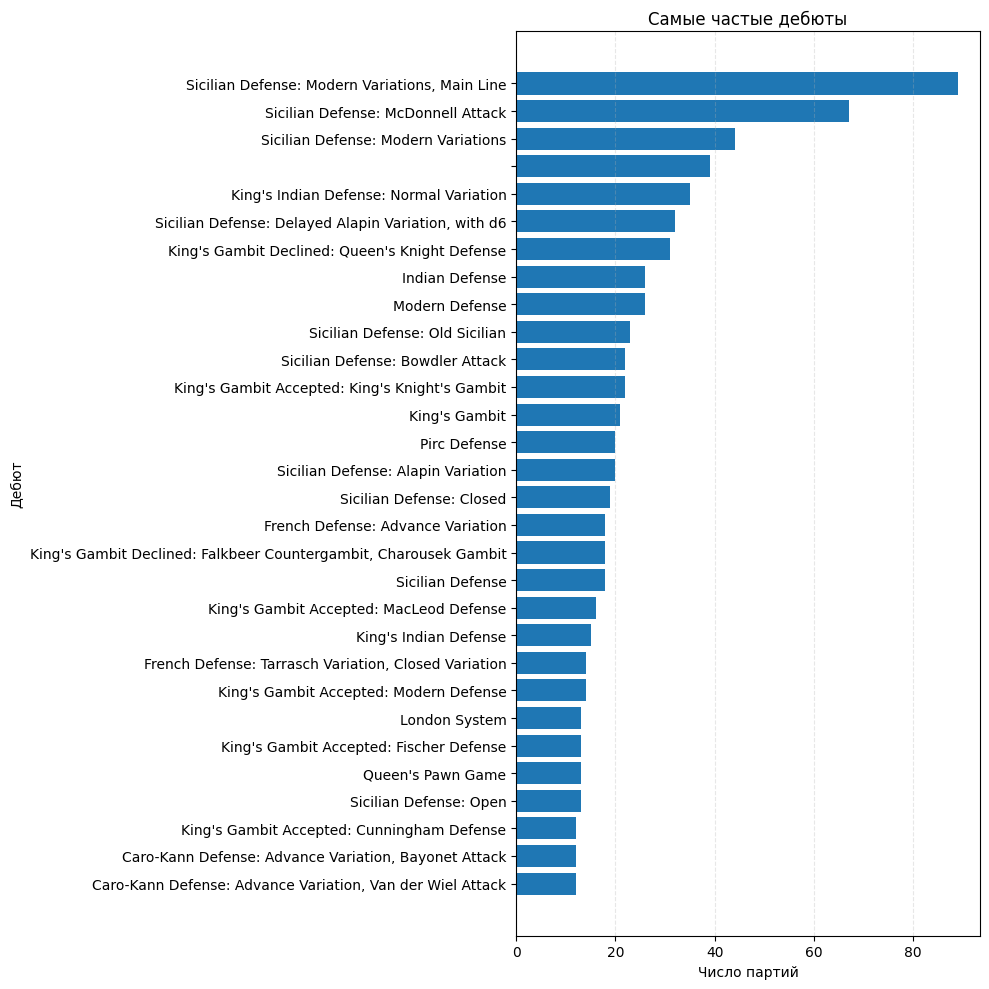

In [23]:
top_openings = df['opening'].value_counts().head(30)

plt.figure(figsize=(10, 10))
plt.barh(top_openings.index[::-1], top_openings.values[::-1])
plt.title('Самые частые дебюты')
plt.xlabel('Число партий')
plt.ylabel('Дебют')
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()

#### Результативность по дебютам

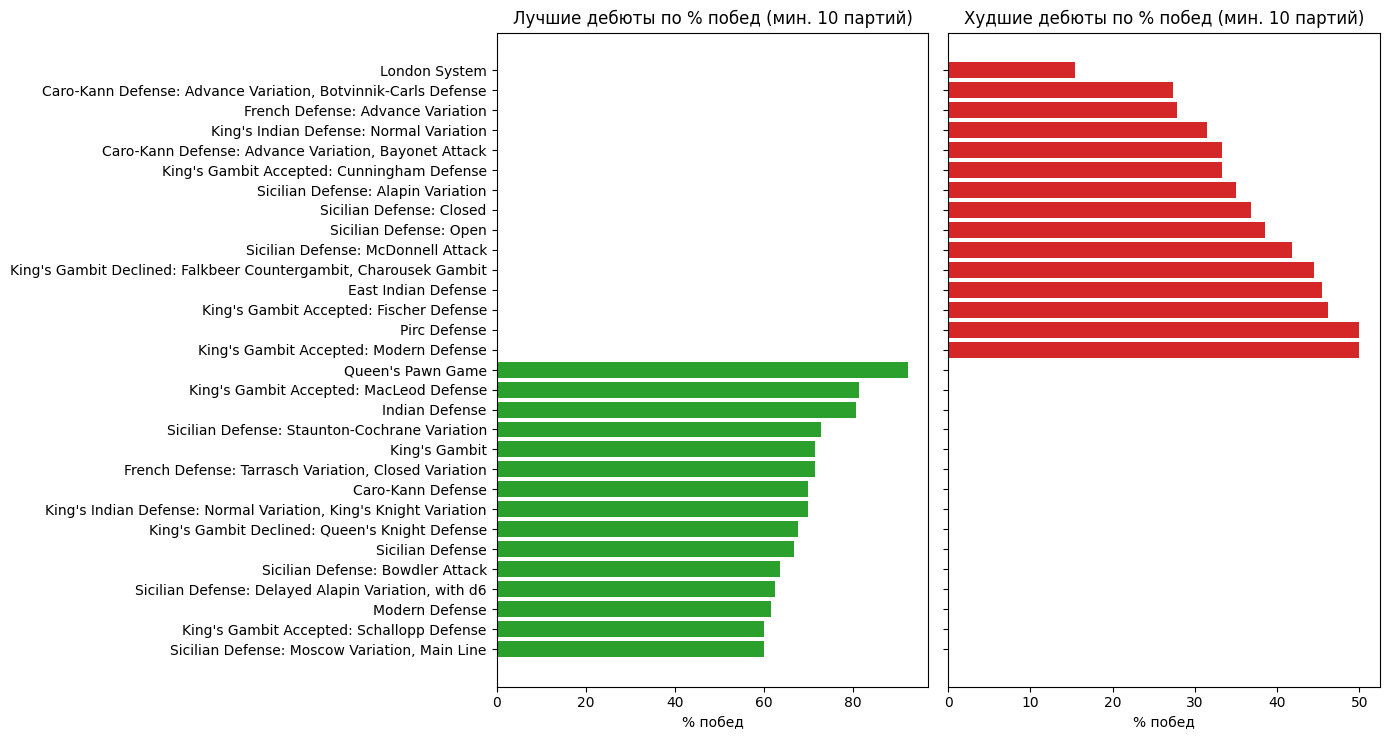

In [24]:
MIN_GAMES_PER_OPENING = 10
TOP_N_OPENINGS = 15

opening_stats = (
    decisive.groupby('opening')['result']
    .value_counts()
    .unstack(fill_value=0)
    .reindex(columns=['win', 'draw', 'loss'], fill_value=0)
)
opening_stats['games'] = opening_stats.sum(axis=1)
opening_stats['win_rate'] = opening_stats['win'] / opening_stats['games'] * 100
opening_stats = opening_stats[opening_stats['games'] >= MIN_GAMES_PER_OPENING]
opening_stats = opening_stats.sort_values('win_rate', ascending=False)

best = opening_stats.head(TOP_N_OPENINGS)
worst = opening_stats.tail(TOP_N_OPENINGS).sort_values('win_rate')

fig, axes = plt.subplots(1, 2, figsize=(14, 0.5 * TOP_N_OPENINGS), sharey=True)
axes[0].barh(best.index[::-1], best['win_rate'][::-1], color='tab:green')
axes[0].set_title(f'Лучшие дебюты по % побед (мин. {MIN_GAMES_PER_OPENING} партий)')
axes[0].set_xlabel('% побед')

axes[1].barh(worst.index[::-1], worst['win_rate'][::-1], color='tab:red')
axes[1].set_title(f'Худшие дебюты по % побед (мин. {MIN_GAMES_PER_OPENING} партий)')
axes[1].set_xlabel('% побед')

plt.tight_layout()

### Распределение партий по типам завершений

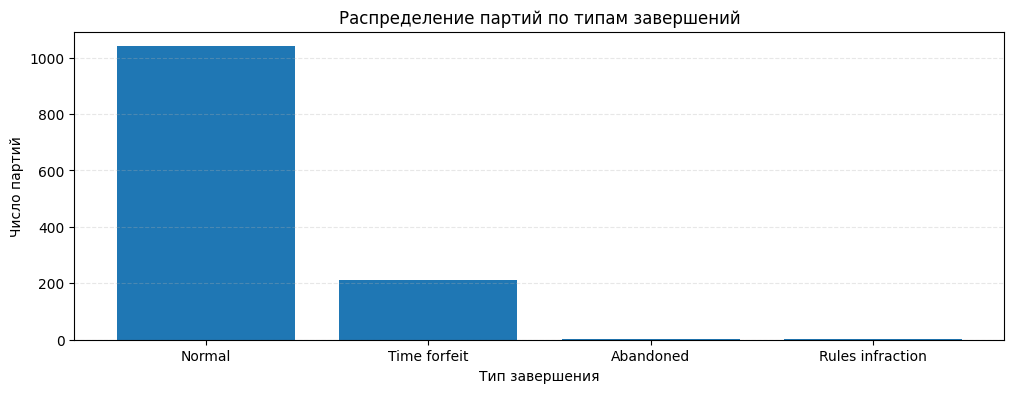

In [25]:
terminations_counts = df['termination'].value_counts()

plt.figure(figsize=(12, 4))
plt.bar(terminations_counts.index, terminations_counts.values)
plt.title('Распределение партий по типам завершений')
plt.xlabel('Тип завершения')
plt.ylabel('Число партий')
plt.grid(axis='y', alpha=0.3, linestyle='--')

#### Типы завершений в разбивке по результату

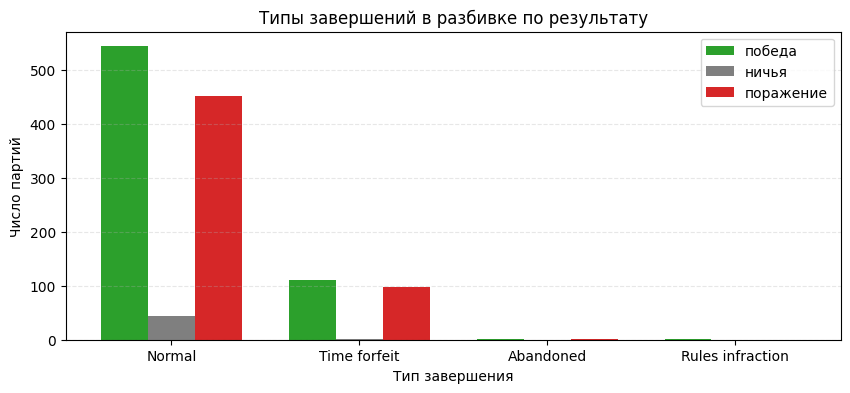

In [26]:
termination_by_result = (
    decisive.groupby('termination')['result']
    .value_counts()
    .unstack(fill_value=0)
    .reindex(columns=['win', 'draw', 'loss'], fill_value=0)
)
termination_by_result = termination_by_result.loc[
    termination_by_result.sum(axis=1).sort_values(ascending=False).index
]

x = range(len(termination_by_result))
plt.figure(figsize=(10, 4))
for i, result in enumerate(['win', 'draw', 'loss']):
    plt.bar(
        [xi + (i - 1) * BAR_GROUP_WIDTH for xi in x],
        termination_by_result[result],
        width=BAR_GROUP_WIDTH,
        label=RESULT_LABELS[result],
        color=RESULT_COLORS[result],
    )
plt.title('Типы завершений в разбивке по результату')
plt.xlabel('Тип завершения')
plt.ylabel('Число партий')
plt.xticks(list(x), termination_by_result.index)
plt.legend()
plt.grid(axis='y', alpha=0.3, linestyle='--')

### Длина партии

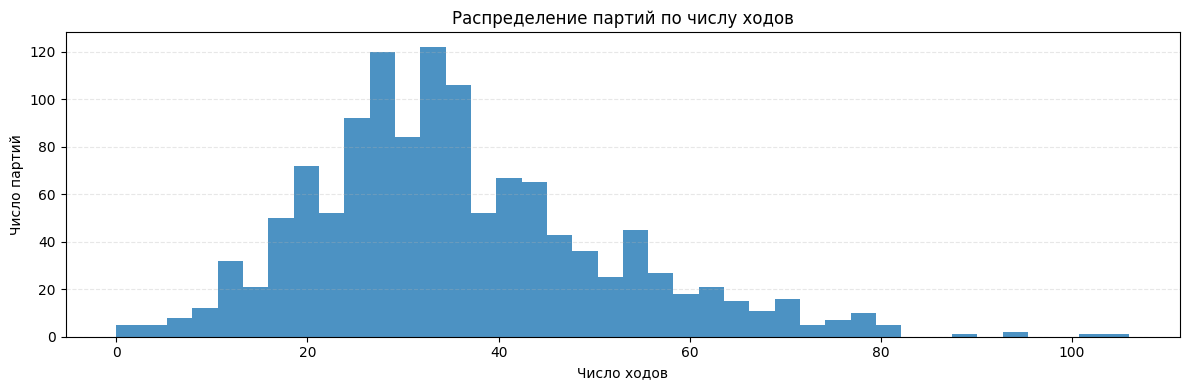

In [27]:
plt.figure(figsize=(12, 4))
plt.hist(df['num_moves'], bins=40, color='tab:blue', alpha=0.8)
plt.title('Распределение партий по числу ходов')
plt.xlabel('Число ходов')
plt.ylabel('Число партий')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()

## Выводы

- **Общий баланс.** Из 1254 партий ни одна не осталась без результата (аборты/отмены отсутствуют) — 53% побед, 44% поражений, 4% ничьих.
- **Белые сильнее чёрных**, как и предсказывает теория: ≈54% побед за белых против ≈51% за чёрных.
- **Результативность растёт вместе с контролем времени**: blitz ≈48% побед, rapid ≈58%, correspondence ≈75% (партий по переписке немного, так что цифра менее статистически устойчива).
- **Рейтинг растёт на длинной дистанции**: blitz поднялся примерно с 1500 (2018) до 1700–1900 (2025–2026), rapid — с ≈1850 до ≈1950, с кратким всплеском выше 2000 в 2024.
- **Дебютный репертуар неравномерен**: Queen's Pawn Game — лучший дебют по результативности (≈92% побед при не менее 10 партий), а London System — худший (≈15% побед) — явный кандидат на пересмотр.
- **Активность концентрируется по вечерам** (19:00–23:00), особенно в пятницу-воскресенье; будние утро и день практически не задействованы.
- **Лучшая серия — 23 победы подряд**, худшая — 11 поражений подряд.
- **Просрочка времени не является основной причиной поражений** — большинство партий заканчиваются матом/сдачей, а исходы по таймауту распределены между победами и поражениями примерно поровну.
- **Типичная партия длится 25–35 ходов.**